In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import joblib

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
DATA_PATH = "../dataset/Final_Augmented_dataset_Diseases_and_Symptoms.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (246945, 378)


In [3]:
df.head()

,diseases,anxiety and nervousness,depression,shortness of breath,depressive or psychotic symptoms,sharp chest pain,dizziness,insomnia,abnormal involuntary movements,chest tightness,...,stuttering or stammering,problems with orgasm,nose deformity,lump over jaw,sore in nose,hip weakness,back swelling,ankle stiffness or tightness,ankle weakness,neck weakness
0,panic disorder,1,0,1,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1,panic disorder,0,0,1,1,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,panic disorder,1,1,1,1,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
3,panic disorder,1,0,0,1,0,1,1,1,0,...,0,0,0,0,0,0,0,0,0,0
4,panic disorder,1,1,0,0,0,0,1,1,1,...,0,0,0,0,0,0,0,0,0,0


In [4]:
df.tail()

,diseases,anxiety and nervousness,depression,shortness of breath,depressive or psychotic symptoms,sharp chest pain,dizziness,insomnia,abnormal involuntary movements,chest tightness,...,stuttering or stammering,problems with orgasm,nose deformity,lump over jaw,sore in nose,hip weakness,back swelling,ankle stiffness or tightness,ankle weakness,neck weakness
246940,open wound of the nose,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
246941,open wound of the nose,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
246942,open wound of the nose,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
246943,open wound of the nose,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
246944,open wound of the nose,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [5]:
df.sample(5)

,diseases,anxiety and nervousness,depression,shortness of breath,depressive or psychotic symptoms,sharp chest pain,dizziness,insomnia,abnormal involuntary movements,chest tightness,...,stuttering or stammering,problems with orgasm,nose deformity,lump over jaw,sore in nose,hip weakness,back swelling,ankle stiffness or tightness,ankle weakness,neck weakness
84417,hypocalcemia,0,0,0,0,1,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
68575,gout,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
177155,fracture of the skull,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
213615,gallstone,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
240655,laryngitis,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [6]:
print("Number of columns:", len(df.columns))

print("\nColumns:")
for i, column in enumerate(df.columns, start=1):
    print(i, "→", column)

Number of columns: 378

Columns:
1 → diseases
2 → anxiety and nervousness
3 → depression
4 → shortness of breath
5 → depressive or psychotic symptoms
6 → sharp chest pain
7 → dizziness
8 → insomnia
9 → abnormal involuntary movements
10 → chest tightness
11 → palpitations
12 → irregular heartbeat
13 → breathing fast
14 → hoarse voice
15 → sore throat
16 → difficulty speaking
17 → cough
18 → nasal congestion
19 → throat swelling
20 → diminished hearing
21 → lump in throat
22 → throat feels tight
23 → difficulty in swallowing
24 → skin swelling
25 → retention of urine
26 → groin mass
27 → leg pain
28 → hip pain
29 → suprapubic pain
30 → blood in stool
31 → lack of growth
32 → emotional symptoms
33 → elbow weakness
34 → back weakness
35 → pus in sputum
36 → symptoms of the scrotum and testes
37 → swelling of scrotum
38 → pain in testicles
39 → flatulence
40 → pus draining from ear
41 → jaundice
42 → mass in scrotum
43 → white discharge from eye
44 → irritable infant
45 → abusing alcohol
46

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 246945 entries, 0 to 246944
Columns: 378 entries, diseases to neck weakness
dtypes: int64(377), str(1)
memory usage: 712.2 MB


In [8]:
missing_values = df.isnull().sum()

print("Total missing values:", missing_values.sum())

missing_values[missing_values > 0]

Total missing values: 0


Series([], dtype: int64)

In [9]:
duplicates = df.duplicated().sum()

print("Duplicate rows:", duplicates)

Duplicate rows: 57298


In [10]:
print(df.columns[-10:])

Index(['stuttering or stammering', 'problems with orgasm', 'nose deformity',
       'lump over jaw', 'sore in nose', 'hip weakness', 'back swelling',
       'ankle stiffness or tightness', 'ankle weakness', 'neck weakness'],
      dtype='str')


In [11]:
print("Last column:", df.columns[-1])
print("First column:", df.columns[0])
print("Total columns:", len(df.columns))

Last column: neck weakness
First column: diseases
Total columns: 378


In [12]:
print(df.head(2).T)

                                               0               1
diseases                          panic disorder  panic disorder
anxiety and nervousness                        1               0
depression                                     0               0
shortness of breath                            1               1
depressive or psychotic symptoms               1               1
...                                          ...             ...
hip weakness                                   0               0
back swelling                                  0               0
ankle stiffness or tightness                   0               0
ankle weakness                                 0               0
neck weakness                                  0               0

[378 rows x 2 columns]


In [13]:
print("Before removing duplicates:", df.shape)

df = df.drop_duplicates().reset_index(drop=True)

print("After removing duplicates:", df.shape)

Before removing duplicates: (246945, 378)
After removing duplicates: (189647, 378)


In [14]:
print("Remaining duplicates:", df.duplicated().sum())

Remaining duplicates: 0


In [15]:
TARGET = "diseases"

X = df.drop(columns=[TARGET])
y = df[TARGET]

print("Features:", X.shape)
print("Target:", y.shape)

Features: (189647, 377)
Target: (189647,)


In [16]:
print("Number of unique diseases:", y.nunique())

Number of unique diseases: 773


In [17]:
print("\nDisease distribution:")
print(y.value_counts())


Disease distribution:
diseases
cystitis                          1219
vulvodynia                        1218
nose disorder                     1218
complex regional pain syndrome    1217
spondylosis                       1216
                                  ... 
rheumatic fever                      1
rocky mountain spotted fever         1
lichen planus                        1
open wound of the jaw                1
kaposi sarcoma                       1
Name: count, Length: 773, dtype: int64


In [18]:
print("Data types:")
print(X.dtypes.value_counts())

Data types:
int64    377
Name: count, dtype: int64


In [19]:
unique_values = set()

for column in X.columns:
    unique_values.update(X[column].dropna().unique())

print("Unique values in symptom columns:")
print(unique_values)

Unique values in symptom columns:
{np.int64(0), np.int64(1)}


In [20]:
print("Missing values:", X.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

Missing values: 0
Duplicate rows: 0


In [21]:
class_counts = y.value_counts()

print("Total diseases:", len(class_counts))
print("Minimum samples in a disease:", class_counts.min())
print("Maximum samples in a disease:", class_counts.max())

print("\nDistribution of number of samples per disease:")
print(class_counts.describe())

Total diseases: 773
Minimum samples in a disease: 1
Maximum samples in a disease: 1219

Distribution of number of samples per disease:
count     773.000000
mean      245.338939
std       333.650389
min         1.000000
25%        10.000000
50%        77.000000
75%       315.000000
max      1219.000000
Name: count, dtype: float64


In [22]:
print("Diseases with only 1 sample:", (class_counts == 1).sum())
print("Diseases with fewer than 5 samples:", (class_counts < 5).sum())
print("Diseases with at least 10 samples:", (class_counts >= 10).sum())
print("Diseases with at least 50 samples:", (class_counts >= 50).sum())

Diseases with only 1 sample: 46
Diseases with fewer than 5 samples: 115
Diseases with at least 10 samples: 587
Diseases with at least 50 samples: 413


In [23]:
MIN_SAMPLES = 10

class_counts = y.value_counts()

valid_diseases = class_counts[
    class_counts >= MIN_SAMPLES
].index

df_ml = df[
    df["diseases"].isin(valid_diseases)
].copy()

df_ml = df_ml.reset_index(drop=True)

print("Original rows:", len(df))
print("Filtered rows:", len(df_ml))

print("Original diseases:", df["diseases"].nunique())
print("Filtered diseases:", df_ml["diseases"].nunique())

Original rows: 189647
Filtered rows: 188920
Original diseases: 773
Filtered diseases: 587


In [24]:
TARGET = "diseases"

X = df_ml.drop(columns=[TARGET])
y = df_ml[TARGET]

print("Features:", X.shape)
print("Target:", y.shape)
print("Number of diseases:", y.nunique())

Features: (188920, 377)
Target: (188920,)


Number of diseases: 587


In [25]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

y_encoded = encoder.fit_transform(y)

print("Number of encoded classes:", len(encoder.classes_))

Number of encoded classes: 587


In [26]:
for i, disease in enumerate(encoder.classes_[:20]):
    print(i, "→", disease)

0 → abdominal aortic aneurysm
1 → abdominal hernia
2 → abscess of nose
3 → abscess of the pharynx
4 → acariasis
5 → achalasia
6 → acne
7 → actinic keratosis
8 → acute bronchiolitis
9 → acute bronchitis
10 → acute bronchospasm
11 → acute glaucoma
12 → acute kidney injury
13 → acute otitis media
14 → acute pancreatitis
15 → acute respiratory distress syndrome (ards)
16 → acute sinusitis
17 → acute stress reaction
18 → adhesive capsulitis of the shoulder
19 → adjustment reaction


In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (151136, 377)
Testing data: (37784, 377)


In [28]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(X_train, y_train)

print("Decision Tree training completed!")

Decision Tree training completed!


In [29]:
dt_pred = dt_model.predict(X_test)

print("Prediction completed!")

Prediction completed!


In [30]:
from sklearn.metrics import accuracy_score

dt_accuracy = accuracy_score(y_test, dt_pred)

print("Decision Tree Accuracy:",
      round(dt_accuracy * 100, 2), "%")

Decision Tree Accuracy: 75.81 %


In [31]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

dt_precision = precision_score(
    y_test,
    dt_pred,
    average="weighted",
    zero_division=0
)

dt_recall = recall_score(
    y_test,
    dt_pred,
    average="weighted",
    zero_division=0
)

dt_f1 = f1_score(
    y_test,
    dt_pred,
    average="weighted",
    zero_division=0
)

print("Decision Tree Results")
print("---------------------")
print("Accuracy :", round(dt_accuracy * 100, 2), "%")
print("Precision:", round(dt_precision * 100, 2), "%")
print("Recall   :", round(dt_recall * 100, 2), "%")
print("F1 Score :", round(dt_f1 * 100, 2), "%")

Decision Tree Results
---------------------
Accuracy : 75.81 %
Precision: 76.34 %
Recall   : 75.81 %
F1 Score : 75.77 %


In [32]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling completed!")

Scaling completed!


In [33]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(
    n_neighbors=5,
    n_jobs=-1
)

knn_model.fit(X_train_scaled, y_train)

print("KNN training completed!")

KNN training completed!


In [34]:
knn_pred = knn_model.predict(X_test_scaled)

print("KNN prediction completed!")

KNN prediction completed!


In [35]:
knn_accuracy = accuracy_score(y_test, knn_pred)

knn_precision = precision_score(
    y_test,
    knn_pred,
    average="weighted",
    zero_division=0
)

knn_recall = recall_score(
    y_test,
    knn_pred,
    average="weighted",
    zero_division=0
)

knn_f1 = f1_score(
    y_test,
    knn_pred,
    average="weighted",
    zero_division=0
)

print("KNN Results")
print("---------------------")
print("Accuracy :", round(knn_accuracy * 100, 2), "%")
print("Precision:", round(knn_precision * 100, 2), "%")
print("Recall   :", round(knn_recall * 100, 2), "%")
print("F1 Score :", round(knn_f1 * 100, 2), "%")

KNN Results
---------------------
Accuracy : 78.23 %
Precision: 79.12 %
Recall   : 78.23 %
F1 Score : 78.28 %


In [36]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=30,
    max_depth=20,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=2
)

rf_model.fit(X_train, y_train)

print("Random Forest training completed!")

Random Forest training completed!


In [37]:
rf_pred = rf_model.predict(X_test)

print("Random Forest prediction completed!")

Random Forest prediction completed!


In [38]:
rf_accuracy = accuracy_score(y_test, rf_pred)

rf_precision = precision_score(
    y_test,
    rf_pred,
    average="weighted",
    zero_division=0
)

rf_recall = recall_score(
    y_test,
    rf_pred,
    average="weighted",
    zero_division=0
)

rf_f1 = f1_score(
    y_test,
    rf_pred,
    average="weighted",
    zero_division=0
)

print("Random Forest Results")
print("---------------------")
print("Accuracy :", round(rf_accuracy * 100, 2), "%")
print("Precision:", round(rf_precision * 100, 2), "%")
print("Recall   :", round(rf_recall * 100, 2), "%")
print("F1 Score :", round(rf_f1 * 100, 2), "%")


Random Forest Results
---------------------
Accuracy : 60.85 %
Precision: 70.7 %
Recall   : 60.85 %
F1 Score : 61.04 %


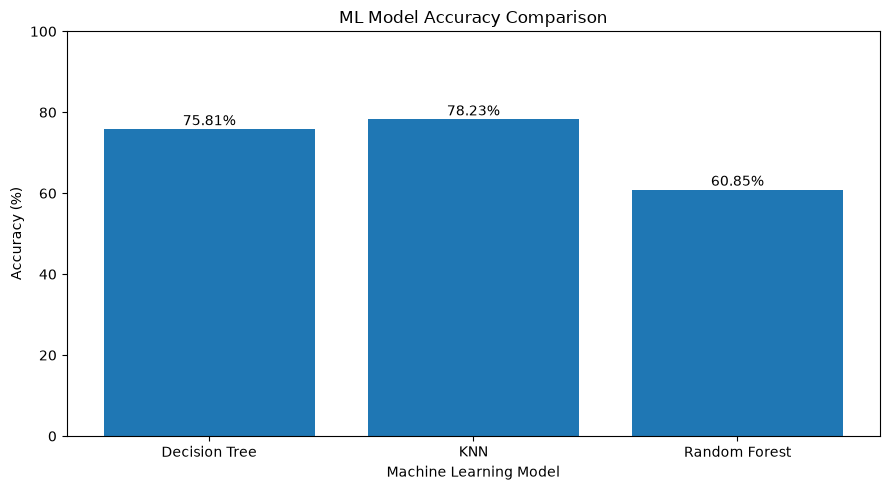

In [39]:
models = ["Decision Tree", "KNN", "Random Forest"]

accuracies = [
    dt_accuracy * 100,
    knn_accuracy * 100,
    rf_accuracy * 100
]

plt.figure(figsize=(9, 5))

bars = plt.bar(models, accuracies)

plt.title("ML Model Accuracy Comparison")
plt.xlabel("Machine Learning Model")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 100)

for bar, accuracy in zip(bars, accuracies):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{accuracy:.2f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()


In [40]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Clustering ke liye sample
cluster_sample = X.sample(
    n=min(10000, len(X)),
    random_state=42
)

print("Clustering sample shape:", cluster_sample.shape)

Clustering sample shape: (10000, 377)


In [41]:
cluster_scaler = StandardScaler()

X_cluster_scaled = cluster_scaler.fit_transform(cluster_sample)

print("Clustering data scaled successfully!")

Clustering data scaled successfully!


In [42]:
inertias = []

k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(X_cluster_scaled)
    inertias.append(kmeans.inertia_)

print("Elbow calculation completed!")

Elbow calculation completed!


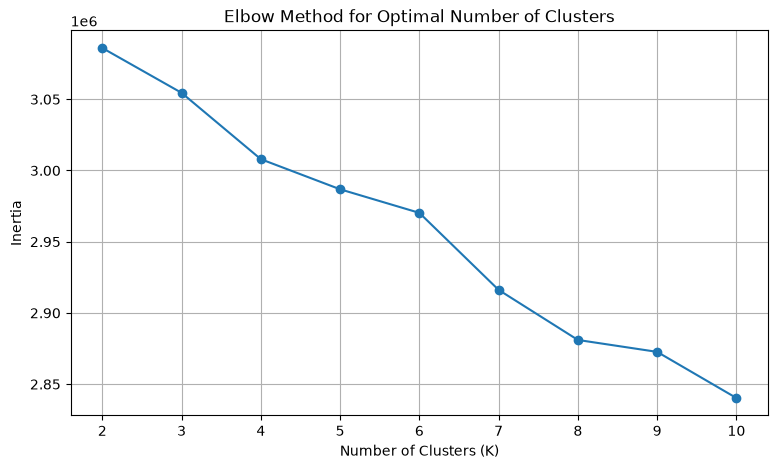

In [43]:
plt.figure(figsize=(9, 5))

plt.plot(k_values, inertias, marker="o")

plt.title("Elbow Method for Optimal Number of Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")

plt.xticks(k_values)
plt.grid(True)

plt.show()

In [44]:
import joblib

joblib.dump(knn_model, "../knn_model.pkl")
joblib.dump(scaler, "../scaler.pkl")
joblib.dump(encoder, "../label_encoder.pkl")

print("Models saved successfully!")

Models saved successfully!


In [45]:
import re

symptom_columns = list(X.columns)

def extract_symptoms(text):
    text = text.lower()
    
    features = []
    
    for symptom in symptom_columns:
        symptom_clean = symptom.lower()
        
        if symptom_clean in text:
            features.append(1)
        else:
            features.append(0)
    
    return features

In [46]:
text = "I have cough, sore throat, dizziness and chest pain"

features = extract_symptoms(text)

print("Detected symptoms:")

for symptom, value in zip(symptom_columns, features):
    if value == 1:
        print("✓", symptom)

Detected symptoms:
✓ dizziness
✓ sore throat
✓ cough


In [47]:
print("Kernel is working!")

Kernel is working!


In [48]:
import joblib
import numpy as np

knn_model = joblib.load("../knn_model.pkl")
scaler = joblib.load("../scaler.pkl")
encoder = joblib.load("../label_encoder.pkl")

print("KNN model loaded!")
print("Scaler loaded!")
print("Label encoder loaded!")

c:\Users\hp\Desktop\ai-healthcare-diagnosis-assistant\venv\Lib\site-packages\joblib\numpy_pickle.py:207: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  array.shape = self.shape


KNN model loaded!
Scaler loaded!
Label encoder loaded!


In [49]:
symptom_columns = list(scaler.feature_names_in_)

print("Total symptoms:", len(symptom_columns))
print("First 10 symptoms:")
print(symptom_columns[:10])

Total symptoms: 377
First 10 symptoms:
['anxiety and nervousness', 'depression', 'shortness of breath', 'depressive or psychotic symptoms', 'sharp chest pain', 'dizziness', 'insomnia', 'abnormal involuntary movements', 'chest tightness', 'palpitations']


In [50]:
symptom_aliases = {
    "shortness of breath": [
        "difficulty breathing",
        "trouble breathing",
        "breathing problem",
        "breathlessness",
        "hard to breathe"
    ],

    "abdominal pain": [
        "stomach pain",
        "stomach ache",
        "belly pain",
        "pain in stomach"
    ],

    "sharp chest pain": [
        "chest pain",
        "pain in chest",
        "chest hurts",
        "pain around chest"
    ],

    "cough": [
        "coughing",
        "cough"
    ],

    "dizziness": [
        "feeling dizzy",
        "dizzy",
        "lightheaded",
        "light headed"
    ],

    "sore throat": [
        "throat pain",
        "painful throat",
        "sore throat"
    ]
}


def extract_symptoms_nlp(text):
    text = text.lower()
    detected = set()

    # Exact symptom matching
    for symptom in symptom_columns:
        if symptom.lower() in text:
            detected.add(symptom)

    # Alias matching
    for symptom, aliases in symptom_aliases.items():
        if symptom in symptom_columns:
            for alias in aliases:
                if alias in text:
                    detected.add(symptom)
                    break

    return list(detected)

In [52]:
def predict_disease(text):

    detected_symptoms = extract_symptoms_nlp(text)

    if len(detected_symptoms) == 0:
        return {
            "disease": None,
            "symptoms": []
        }

    feature_vector = np.array([
        1 if symptom in detected_symptoms else 0
        for symptom in symptom_columns
    ]).reshape(1, -1)

    scaled_features = scaler.transform(feature_vector)

    prediction = knn_model.predict(scaled_features)

    disease = encoder.inverse_transform(prediction)[0]

    return {
        "disease": disease,
        "symptoms": detected_symptoms
    } 

In [53]:
result = predict_disease(
    "I have cough, sore throat, dizziness and chest pain"
)

print("Detected Symptoms:")
for symptom in result["symptoms"]:
    print("✓", symptom)

print("\nPredicted Disease:")
print(result["disease"])

c:\Users\hp\Desktop\ai-healthcare-diagnosis-assistant\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Detected Symptoms:
✓ cough
✓ dizziness
✓ sharp chest pain
✓ sore throat

Predicted Disease:
atelectasis
